In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [48]:
bobcat_df = pd.read_csv('bobcatData.csv')
rabbit_df = pd.read_csv('rabbitData.csv')

In [49]:
print("First CSV file:")
print(bobcat_df.head())

print("\nSecond CSV file:")
print(rabbit_df.head())

First CSV file:
   # Day   Bobcats
0      4       107
1      5       111
2      6        93
3      8        92
4      9        90

Second CSV file:
   # Day   Rabbits
0      0       140
1      1       128
2      3       150
3      5       133
4      6       134


In [50]:
# Create a complete range of days from 1 to 90
complete_days = pd.Series(np.arange(0, 91), name='# Day')

# Reindex the DataFrames to include all days from 1 to 90
bobcat_df = bobcat_df.set_index('# Day').reindex(complete_days).reset_index()
rabbit_df = rabbit_df.set_index('# Day').reindex(complete_days).reset_index()

# Display the DataFrames with missing values set to NaN
print("Bobcat DataFrame with missing values set to NaN:")
print(bobcat_df.head(15))

print("\nRabbit DataFrame with missing values set to NaN:")
print(rabbit_df.head(15))

Bobcat DataFrame with missing values set to NaN:
    # Day   Bobcats
0       0       NaN
1       1       NaN
2       2       NaN
3       3       NaN
4       4     107.0
5       5     111.0
6       6      93.0
7       7       NaN
8       8      92.0
9       9      90.0
10     10       NaN
11     11      91.0
12     12      84.0
13     13      92.0
14     14       NaN

Rabbit DataFrame with missing values set to NaN:
    # Day   Rabbits
0       0     140.0
1       1     128.0
2       2       NaN
3       3     150.0
4       4       NaN
5       5     133.0
6       6     134.0
7       7       NaN
8       8     147.0
9       9     143.0
10     10     152.0
11     11     144.0
12     12     136.0
13     13     151.0
14     14     150.0


In [51]:
bobcat_df.set_index('# Day', inplace=True)
rabbit_df.set_index('# Day', inplace=True)

print("Bobcat DataFrame with '# Day' as index:")
print(bobcat_df.head())

print("\nRabbit DataFrame with '# Day' as index:")
print(rabbit_df.head())

Bobcat DataFrame with '# Day' as index:
       Bobcats
# Day         
0          NaN
1          NaN
2          NaN
3          NaN
4        107.0

Rabbit DataFrame with '# Day' as index:
       Rabbits
# Day         
0        140.0
1        128.0
2          NaN
3        150.0
4          NaN


In [52]:
print(bobcat_df.columns)

Index([' Bobcats'], dtype='object')


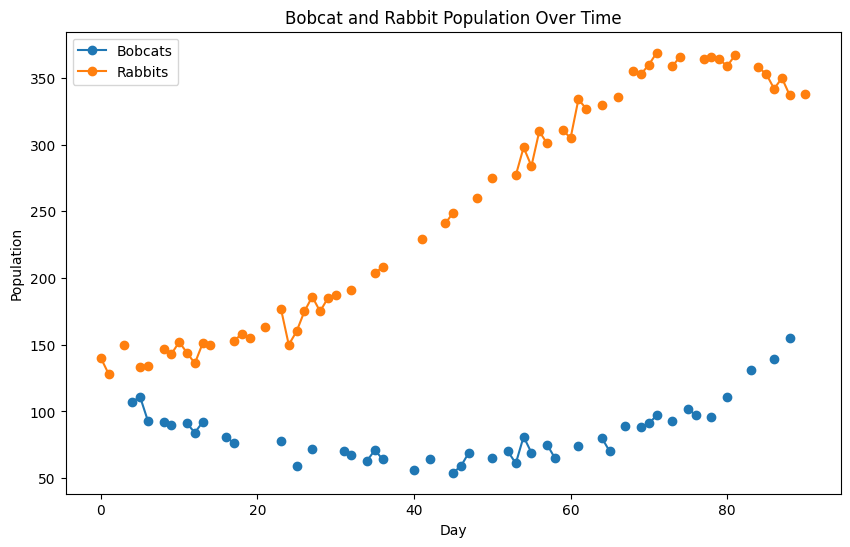

In [53]:
plt.figure(figsize=(10, 6))

# Plotting Bobcat data
plt.plot(bobcat_df.index, bobcat_df[' Bobcats'], label='Bobcats', marker='o')

# Plotting Rabbit data
plt.plot(rabbit_df.index, rabbit_df[' Rabbits'], label='Rabbits', marker='o')

# Adding titles and labels
plt.title('Bobcat and Rabbit Population Over Time')
plt.xlabel('Day')
plt.ylabel('Population')
plt.legend()

# Display the plot
plt.show()

Mean Squared Error by Spline Order for Bobcats:
Order 1: 41.8678
Order 2: 88.8437
Order 3: 96.3262
Order 4: 104.7463

Mean Squared Error by Spline Order for Rabbits:
Order 1: 62.4440
Order 2: 397.6838
Order 3: 114.5775
Order 4: 151.4942


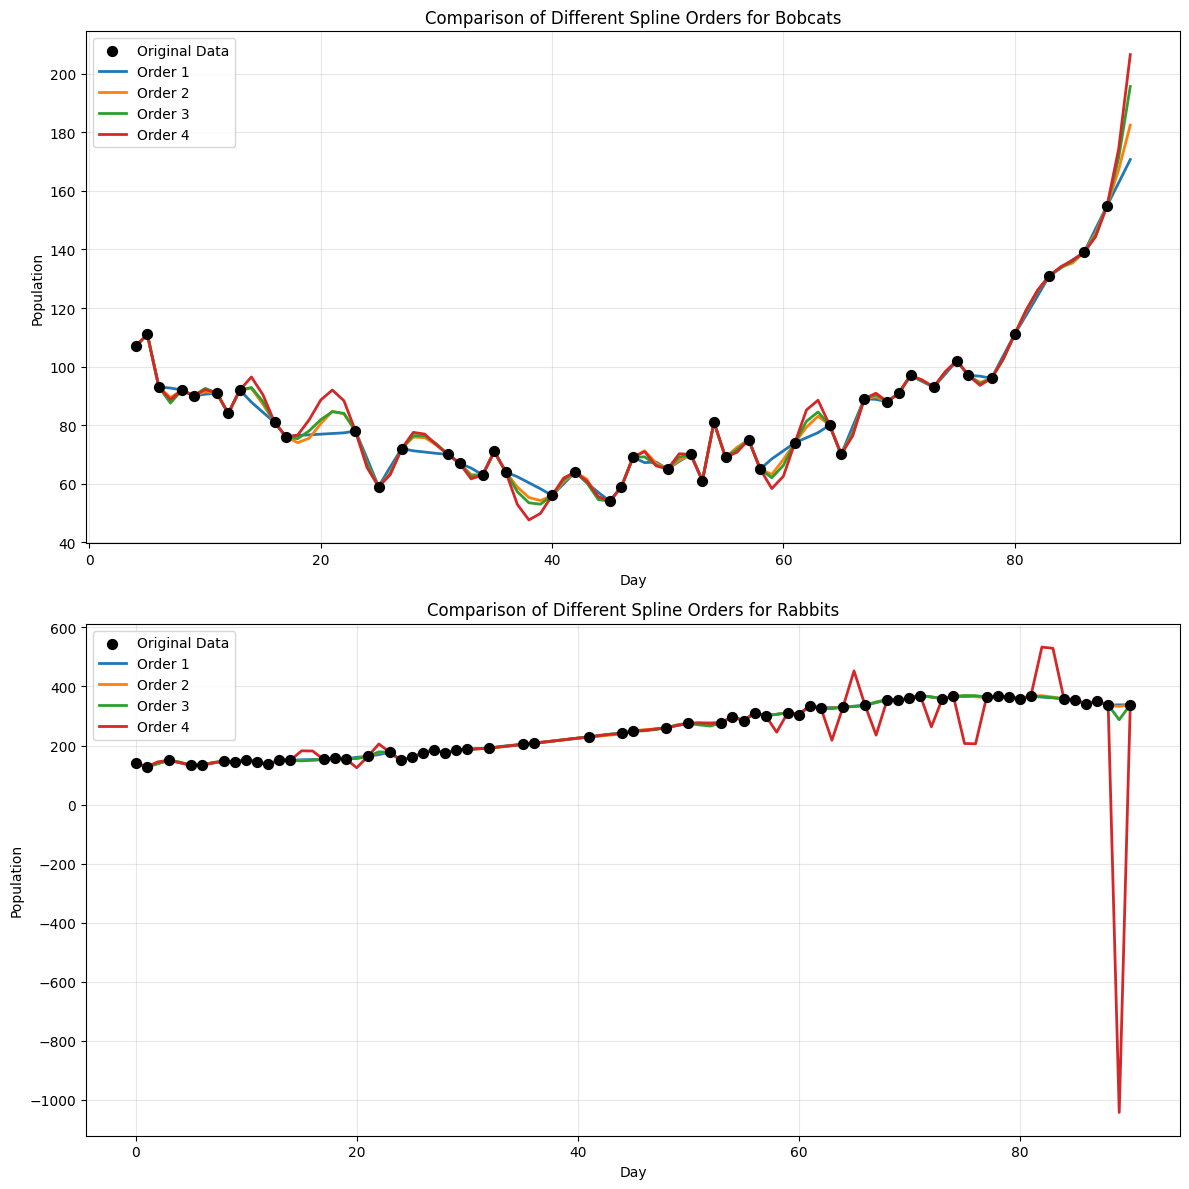

In [65]:
# Define a function to calculate MSE for different spline orders
def compare_spline_orders(df, column_name):
    known_data = df[~df[column_name].isna()].copy()
    
    if len(known_data) > 5:
        errors = {}
        for order in range(1, 5):
            # Create artificial gaps
            test_df = known_data.copy()
            # Mask every 3rd value for testing
            test_mask = np.arange(len(test_df)) % 3 == 0
            actual_values = test_df.loc[test_mask, column_name].copy()
            test_df.loc[test_mask, column_name] = np.nan
            
            # Interpolate
            interpolated = test_df.interpolate(method='spline', order=order)
            
            # Calculate error
            predicted_values = interpolated.loc[test_mask, column_name]
            mse = ((actual_values - predicted_values) ** 2).mean()
            errors[order] = mse
        
        return errors
    return None

# Calculate MSE for different orders
bobcat_errors = compare_spline_orders(bobcat_df, ' Bobcats')
rabbit_errors = compare_spline_orders(rabbit_df, ' Rabbits')

# Print MSE results
print("Mean Squared Error by Spline Order for Bobcats:")
for order, error in bobcat_errors.items():
    print(f"Order {order}: {error:.4f}")

print("\nMean Squared Error by Spline Order for Rabbits:")
for order, error in rabbit_errors.items():
    print(f"Order {order}: {error:.4f}")

# Visualize different spline orders for both datasets
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Bobcat visualization
ax = axes[0]
# Plot original data points
mask = ~bobcat_df[' Bobcats'].isna()
ax.scatter(bobcat_df.index[mask], bobcat_df[' Bobcats'][mask], 
           color='black', label='Original Data', zorder=10, s=50)

# Plot different interpolation orders
for order in range(1, 5):
    interpolated = bobcat_df.interpolate(method='spline', order=order)
    ax.plot(interpolated.index, interpolated[' Bobcats'], 
             label=f'Order {order}', linewidth=2)

ax.set_title('Comparison of Different Spline Orders for Bobcats')
ax.set_xlabel('Day')
ax.set_ylabel('Population')
ax.legend()
ax.grid(True, alpha=0.3)

# Rabbit visualization
ax = axes[1]
# Plot original data points
mask = ~rabbit_df[' Rabbits'].isna()
ax.scatter(rabbit_df.index[mask], rabbit_df[' Rabbits'][mask], 
           color='black', label='Original Data', zorder=10, s=50)

# Plot different interpolation orders
for order in range(1, 5):
    interpolated = rabbit_df.interpolate(method='spline', order=order)
    ax.plot(interpolated.index, interpolated[' Rabbits'], 
             label=f'Order {order}', linewidth=2)

ax.set_title('Comparison of Different Spline Orders for Rabbits')
ax.set_xlabel('Day')
ax.set_ylabel('Population')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [68]:
# First apply interpolation as you did
bobcat_interpolated = bobcat_df.interpolate(method='spline', order=1, fill_value='extrapolate')
rabbit_interpolated = rabbit_df.interpolate(method='spline', order=1, fill_value='extrapolate')

# Now handle any remaining NaN values with forward fill followed by backward fill
# Using the recommended methods instead of the deprecated approach
bobcat_interpolated = bobcat_interpolated.ffill().bfill()
rabbit_interpolated = rabbit_interpolated.ffill().bfill()

# Check if any NaN values remain
print("Bobcat dataset - NaN values after filling:", 
      bobcat_interpolated[' Bobcats'].isna().sum())
print("Rabbit dataset - NaN values after filling:", 
      rabbit_interpolated[' Rabbits'].isna().sum())

Bobcat dataset - NaN values after filling: 0
Rabbit dataset - NaN values after filling: 0


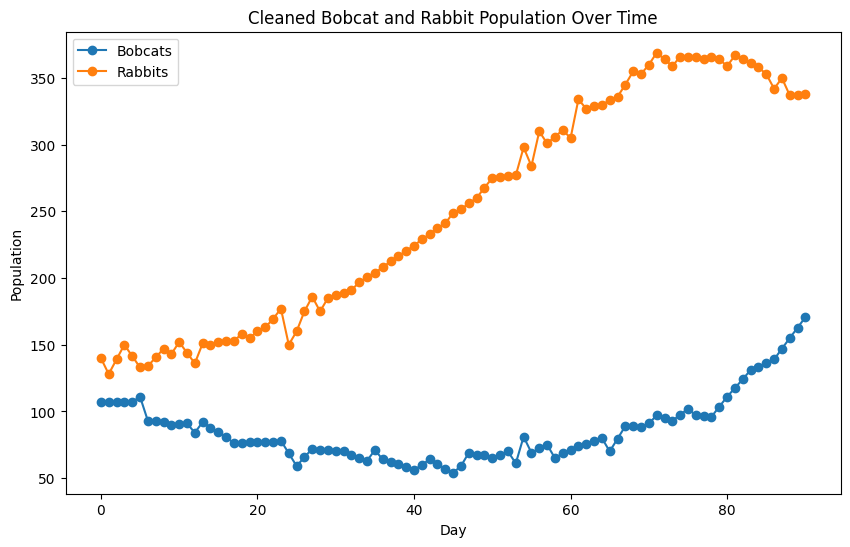

In [70]:
plt.figure(figsize=(10, 6))

# Plotting Bobcat data
plt.plot(bobcat_interpolated.index, bobcat_interpolated[' Bobcats'], label='Bobcats', marker='o')

# Plotting Rabbit data
plt.plot(rabbit_interpolated.index, rabbit_interpolated[' Rabbits'], label='Rabbits', marker='o')

# Adding titles and labels
plt.title('Cleaned Bobcat and Rabbit Population Over Time')
plt.xlabel('Day')
plt.ylabel('Population')
plt.legend()

# Display the plot
plt.show()

In [71]:
# Save the cleaned datasets to CSV files
bobcat_interpolated.to_csv('cleaned_bobcat_data.csv', index=True)
rabbit_interpolated.to_csv('cleaned_rabbit_data.csv', index=True)

print("Cleaned datasets have been saved.")

Cleaned datasets have been saved.
